# Evaluate GT Tracks

Set the paths and parameters below, then run the evaluation. The script writes a manifest, row table, Zarr feature arrays, and candidate-pair diagnostics.

In [66]:
from pathlib import Path
import importlib.util
import sys

repo_root = Path.cwd().resolve()
while repo_root != repo_root.parent and not (repo_root / "scripts" / "evaluation" / "eval_GT_tracks.py").exists():
    repo_root = repo_root.parent
src_path = repo_root / "src"
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))
script_path = repo_root / "scripts" / "evaluation" / "eval_GT_tracks.py"
spec = importlib.util.spec_from_file_location("eval_GT_tracks", script_path)
eval_gt_tracks = importlib.util.module_from_spec(spec)
sys.modules[spec.name] = eval_gt_tracks
spec.loader.exec_module(eval_gt_tracks)

In [67]:
gt_segmentation_path = Path("/nfs/scratch2/inacio/data/llsm/spatialdino/model_final/results/simulated_new/fast/GT/n_300/volumes/seg/")
inference_output_path = Path("/nfs/scratch2/inacio/data/llsm/spatialdino/model_final/results/simulated_new/fast/SNR_10/n_300/nope_global/")
output_path = Path("/nfs/scratch2/inacio/data/llsm/spatialdino/model_final/results/simulated_new/fast/SNR_10/n_300/test_optimal/")

params = eval_gt_tracks.EvaluationParams(
    max_gap=10,
    num_features="tracking",  # "tracking" = first 384 channels; use "all" or an integer if needed
    max_distance_xy=35.0,
    max_distance_z=15.0,
    z_distance_weight=2.5,
    dice_threshold=0.5,
    corr_threshold=0.5,
    no_compression=True,
    export_wide_csv=False,
    candidate_output="full",  # "summary" skips the huge per-candidate table; "none" skips candidate diagnostics
    candidate_batch_rows=100_000,
    overwrite=True,
    feature_cache_bytes=64 * 1024**3,
    num_workers=8,
)

manifest_path = eval_gt_tracks.run_evaluation(
    inference_output_path,
    gt_segmentation_path=gt_segmentation_path,
    output_path=output_path,
    params=params,
)
manifest_path

[eval_GT_tracks] Found 50 timepoints; evaluating 384 feature channels
[eval_GT_tracks] Preparing 00 (1/50)
[eval_GT_tracks] Preparing 01 (2/50)
[eval_GT_tracks] Preparing 02 (3/50)
[eval_GT_tracks] Preparing 03 (4/50)
[eval_GT_tracks] Preparing 04 (5/50)
[eval_GT_tracks] Preparing 05 (6/50)
[eval_GT_tracks] Preparing 06 (7/50)
[eval_GT_tracks] Preparing 07 (8/50)
[eval_GT_tracks] Preparing 08 (9/50)
[eval_GT_tracks] Preparing 09 (10/50)
[eval_GT_tracks] Preparing 10 (11/50)
[eval_GT_tracks] Preparing 11 (12/50)
[eval_GT_tracks] Preparing 12 (13/50)
[eval_GT_tracks] Preparing 13 (14/50)
[eval_GT_tracks] Preparing 14 (15/50)
[eval_GT_tracks] Preparing 15 (16/50)
[eval_GT_tracks] Preparing 16 (17/50)
[eval_GT_tracks] Preparing 17 (18/50)
[eval_GT_tracks] Preparing 18 (19/50)
[eval_GT_tracks] Preparing 19 (20/50)
[eval_GT_tracks] Preparing 20 (21/50)
[eval_GT_tracks] Preparing 21 (22/50)
[eval_GT_tracks] Preparing 22 (23/50)
[eval_GT_tracks] Preparing 23 (24/50)
[eval_GT_tracks] Preparing 

PosixPath('/nfs/scratch2/inacio/data/llsm/spatialdino/model_final/results/simulated_new/fast/SNR_10/n_300/test_optimal/manifest.json')

In [5]:
import json
import zarr

manifest = json.loads(manifest_path.read_text())
manifest["outputs"]

{'candidate_pairs': 'candidate_pairs.parquet',
 'candidate_ref_summary': 'candidate_ref_summary.parquet',
 'feature_means': 'feature_means.zarr',
 'gt_rows': 'gt_rows.parquet',
 'true_gap_corr': 'true_gap_corr.zarr',
 'true_gap_mse': 'true_gap_mse.zarr',
 'wide_csv': None}

In [6]:
feature_means = zarr.open(output_path / manifest["outputs"]["feature_means"], mode="r")
true_gap_corr = zarr.open(output_path / manifest["outputs"]["true_gap_corr"], mode="r")
true_gap_mse = zarr.open(output_path / manifest["outputs"]["true_gap_mse"], mode="r")

feature_means.shape, true_gap_corr.shape, true_gap_mse.shape

((15000, 384), (15000, 10, 384), (15000, 10, 384))

In [25]:
import pandas as pd
import numpy as np

manifest = json.loads((output_path / "manifest.json").read_text())                                                                                
                                                                                                                                                    
gt = pd.read_parquet(output_path / manifest["outputs"]["gt_rows"])                                                                                
feature_means = zarr.open(output_path / manifest["outputs"]["feature_means"], mode="r")

In [22]:
row = gt.query("track_id == 17").iloc[0]
idx = int(row["row_index"])

feat_vec = feature_means[idx, :]

In [23]:
feat_vec.shape

(384,)

In [26]:
track_rows = gt.query("track_id == @i").sort_values("frame")

  max_gap = int(manifest["max_gap"])
  dice_cols = [f"dice_gap_{gap}" for gap in range(1, max_gap + 1)]

  dice_arr = track_rows[dice_cols].to_numpy(dtype=float)

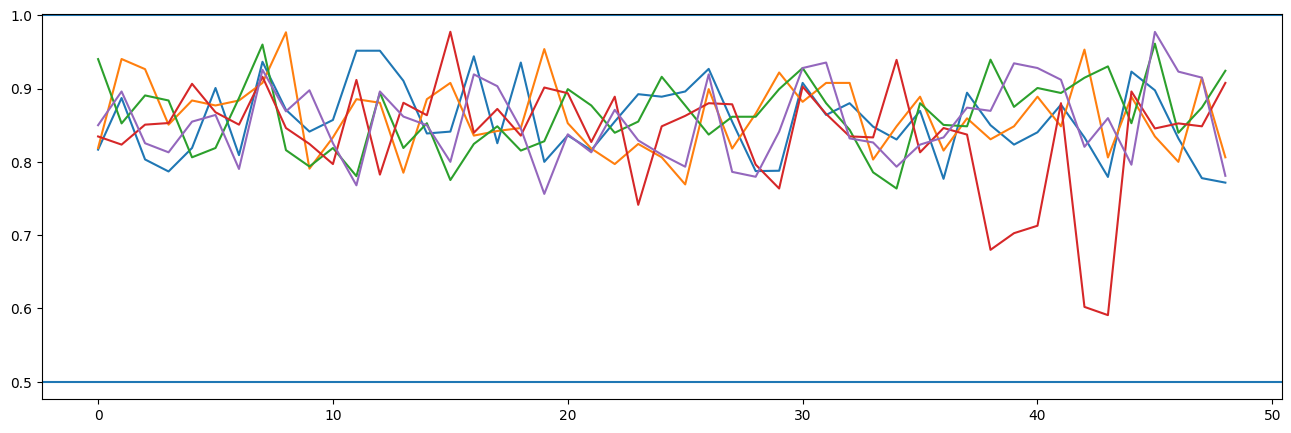

In [65]:
import matplotlib.pyplot as plt

max_gap = int(manifest["max_gap"])

plt.figure(figsize=(16,5))
for i in [1,2,3,4,5]:

    track_rows = gt.query("track_id == @i").sort_values("frame")

    
    # row_indices = track_rows["row_index"].to_numpy(dtype=int)
    # feat_vec = np.asarray(feature_means[row_indices, :])
    # plt.plot(feat_vec.mean(axis=1))

    dice_cols = [f"dice_gap_{gap}" for gap in range(1, max_gap + 1)]
    dice_arr = track_rows[dice_cols].to_numpy(dtype=float)
    
    plt.plot(dice_arr[:,0])
plt.axhline(y=0.5)
plt.axhline(y=1)
plt.show()

In [57]:
dice_arr[dice_arr>0].min()

np.float64(0.6862745098039216)